**CS:GO COMPLETE ANALYSIS**

Combining Professional Match Data & Competitive Matchmaking Data

CS:GO is one of the most popular competitive FPS games in the world. In this project, we analyze both professional tournament data and real matchmaking game data to uncover patterns in team performance, map popularity, weapon effectiveness, and player behavior.

**IMPORTING THE LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**LOADING THE DATASET**

In [2]:
# Professional match results
results = pd.read_csv('/kaggle/input/datasets/mateusdmachado/csgo-professional-matches/results.csv')

# Professional player stats
players = pd.read_csv('/kaggle/input/datasets/mateusdmachado/csgo-professional-matches/players.csv')

# Matchmaking damage data
dmg = pd.read_csv('/kaggle/input/datasets/skihikingkevin/csgo-matchmaking-damage/esea_master_dmg_demos.part1.csv')

# Matchmaking kills data
kills = pd.read_csv('/kaggle/input/datasets/skihikingkevin/csgo-matchmaking-damage/esea_master_kills_demos.part1.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


**EXPLORING ROWS AND COLUMNS**

In [3]:
print(f"Shape: {results.shape}")
results.info()

Shape: (45773, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45773 entries, 0 to 45772
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          45773 non-null  object
 1   team_1        45773 non-null  object
 2   team_2        45773 non-null  object
 3   _map          45773 non-null  object
 4   result_1      45773 non-null  int64 
 5   result_2      45773 non-null  int64 
 6   map_winner    45773 non-null  int64 
 7   starting_ct   45773 non-null  int64 
 8   ct_1          45773 non-null  int64 
 9   t_2           45773 non-null  int64 
 10  t_1           45773 non-null  int64 
 11  ct_2          45773 non-null  int64 
 12  event_id      45773 non-null  int64 
 13  match_id      45773 non-null  int64 
 14  rank_1        45773 non-null  int64 
 15  rank_2        45773 non-null  int64 
 16  map_wins_1    45773 non-null  int64 
 17  map_wins_2    45773 non-null  int64 
 18  match_winner  45773 non-nul

In [4]:
print(f"Shape: {players.shape}")
players.info()

Shape: (383317, 101)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383317 entries, 0 to 383316
Columns: 101 entries, date to m3_rating_t
dtypes: float64(76), int64(16), object(9)
memory usage: 295.4+ MB


In [5]:
print(f"Shape: {dmg.shape}")
dmg.info()

Shape: (5992097, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992097 entries, 0 to 5992096
Data columns (total 23 columns):
 #   Column           Dtype  
---  ------           -----  
 0   file             object 
 1   round            int64  
 2   tick             int64  
 3   seconds          float64
 4   att_team         object 
 5   vic_team         object 
 6   att_side         object 
 7   vic_side         object 
 8   hp_dmg           int64  
 9   arm_dmg          int64  
 10  is_bomb_planted  bool   
 11  bomb_site        object 
 12  hitbox           object 
 13  wp               object 
 14  wp_type          object 
 15  att_id           int64  
 16  att_rank         int64  
 17  vic_id           int64  
 18  vic_rank         int64  
 19  att_pos_x        float64
 20  att_pos_y        float64
 21  vic_pos_x        float64
 22  vic_pos_y        float64
dtypes: bool(1), float64(5), int64(8), object(9)
memory usage: 1011.5+ MB


In [6]:
print(f"Shape: {kills.shape}")
kills.info()

Shape: (1569477, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569477 entries, 0 to 1569476
Data columns (total 13 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   file             1569477 non-null  object 
 1   round            1569477 non-null  int64  
 2   tick             1569477 non-null  int64  
 3   seconds          1569342 non-null  float64
 4   att_team         1569477 non-null  object 
 5   vic_team         1569477 non-null  object 
 6   att_side         1569477 non-null  object 
 7   vic_side         1569477 non-null  object 
 8   wp               1569477 non-null  object 
 9   wp_type          1569477 non-null  object 
 10  ct_alive         1569477 non-null  int64  
 11  t_alive          1569477 non-null  int64  
 12  is_bomb_planted  1569477 non-null  bool   
dtypes: bool(1), float64(1), int64(4), object(7)
memory usage: 145.2+ MB


**DATA CLEANING**

Before analysis we check for missing values in all four datasets and handle them appropriately.

In [7]:
print("Missing Values - Results:")
print(results.isnull().sum())
print("\nMissing Values - Players:")
print(players.isnull().sum().sum(), "total missing values")
print("\nMissing Values - Damage:")
print(dmg.isnull().sum())
print("\nMissing Values - Kills:")
print(kills.isnull().sum())

Missing Values - Results:
date            0
team_1          0
team_2          0
_map            0
result_1        0
result_2        0
map_winner      0
starting_ct     0
ct_1            0
t_2             0
t_1             0
ct_2            0
event_id        0
match_id        0
rank_1          0
rank_2          0
map_wins_1      0
map_wins_2      0
match_winner    0
dtype: int64

Missing Values - Players:
16000600 total missing values

Missing Values - Damage:
file                     0
round                    0
tick                     0
seconds                515
att_team                 0
vic_team                 0
att_side             59017
vic_side                 0
hp_dmg                   0
arm_dmg                  0
is_bomb_planted          0
bomb_site          5129343
hitbox                   0
wp                       0
wp_type                  0
att_id                   0
att_rank                 0
vic_id                   0
vic_rank                 0
att_pos_x              

Based on the null check:
- **Results**: No missing values — no cleaning needed.
- **Players**: 16,000,600 missing values — fill with 0 since missing stats mean the player didn't record that value
- **Damage**: `seconds` has 515 nulls → drop those rows. `att_side` has 59,017 nulls → drop those rows. `bomb_site` has 5,129,343 nulls → this is expected since bomb_site is only recorded when bomb is planted, keep as is
- **Kills**: `seconds` has 135 nulls → drop those rows

In [8]:
# Players - fill missing stats with 0
players.fillna(0, inplace=True)

# Damage - drop rows where seconds or att_side is null
dmg.dropna(subset=['seconds', 'att_side'], inplace=True)

# Kills - drop rows where seconds is null
kills.dropna(subset=['seconds'], inplace=True)

print("Cleaning done!")
print(f"Damage shape after cleaning: {dmg.shape}")
print(f"Kills shape after cleaning: {kills.shape}")

Cleaning done!
Damage shape after cleaning: (5932571, 23)
Kills shape after cleaning: (1569342, 13)


**ANALYSIS & VISUALIZATIONS**

**Q1: Which map is most played in professional matches?**

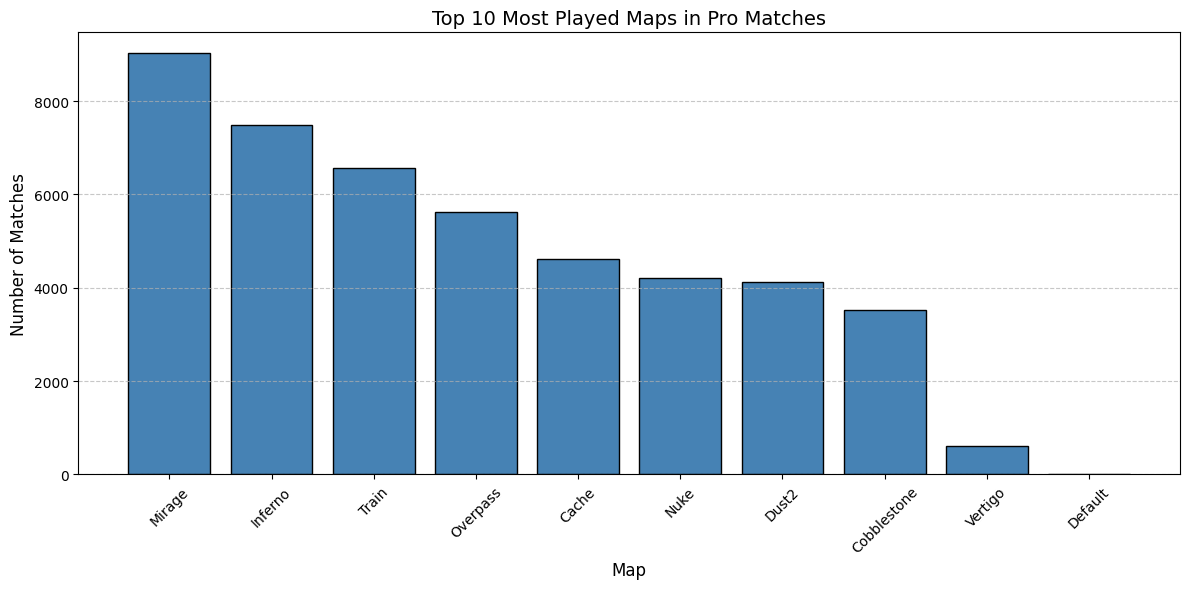

Most played map: Mirage with 9021 matches


In [9]:
map_counts = results['_map'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(map_counts.index, map_counts.values, color='steelblue', edgecolor='black')
plt.title('Top 10 Most Played Maps in Pro Matches', fontsize=14)
plt.xlabel('Map', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Most played map: {map_counts.index[0]} with {map_counts.values[0]} matches")

**Q2: Which team wins the most professional matches?**

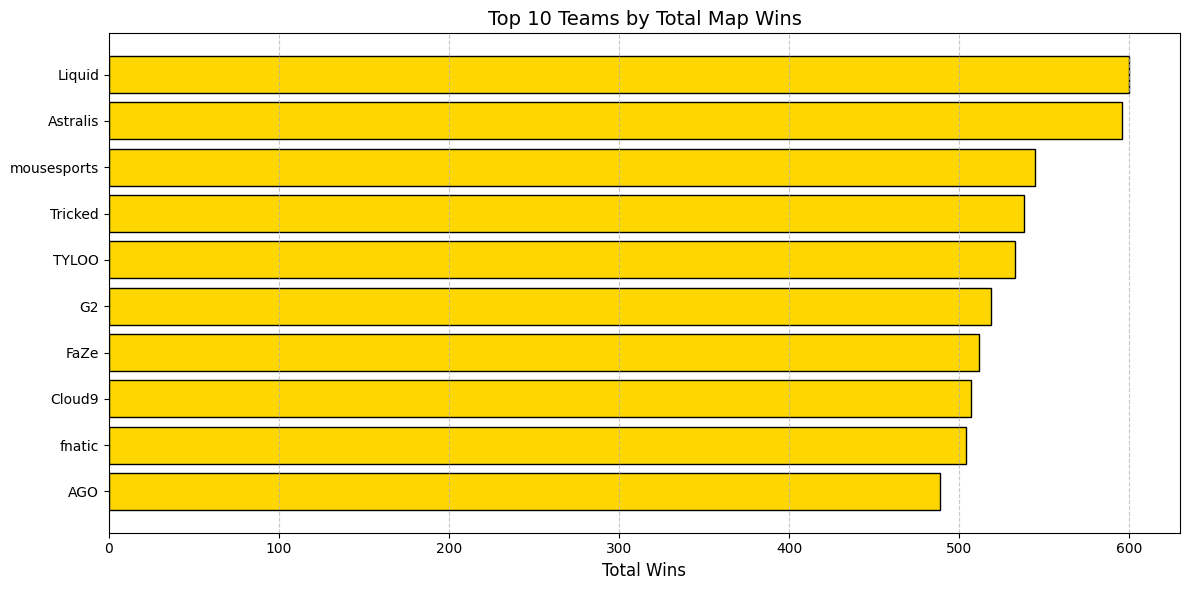

Most successful team: Liquid with 600 wins


In [10]:
team1_wins = results[results['map_winner'] == 1]['team_1'].value_counts()
team2_wins = results[results['map_winner'] == 2]['team_2'].value_counts()

total_wins = team1_wins.add(team2_wins, fill_value=0).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(total_wins.index[::-1], total_wins.values[::-1], color='gold', edgecolor='black')
plt.title('Top 10 Teams by Total Map Wins', fontsize=14)
plt.xlabel('Total Wins', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Most successful team: {total_wins.index[0]} with {int(total_wins.values[0])} wins")

**Q3: Which side wins more rounds — CT or T?**

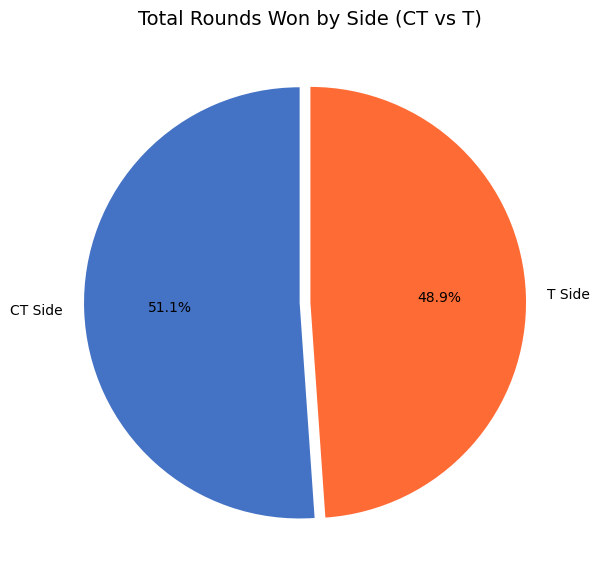

CT rounds won: 594820
T rounds won: 569089


In [11]:
ct_rounds = results['ct_1'].sum() + results['ct_2'].sum()
t_rounds = results['t_1'].sum() + results['t_2'].sum()

labels = ['CT Side', 'T Side']
values = [ct_rounds, t_rounds]

plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#4472C4', '#FF6B35'], explode=(0.05, 0))
plt.title('Total Rounds Won by Side (CT vs T)', fontsize=14)
plt.show()

print(f"CT rounds won: {ct_rounds}")
print(f"T rounds won: {t_rounds}")

**Q4: Which weapon deals the most total damage in matchmaking?**

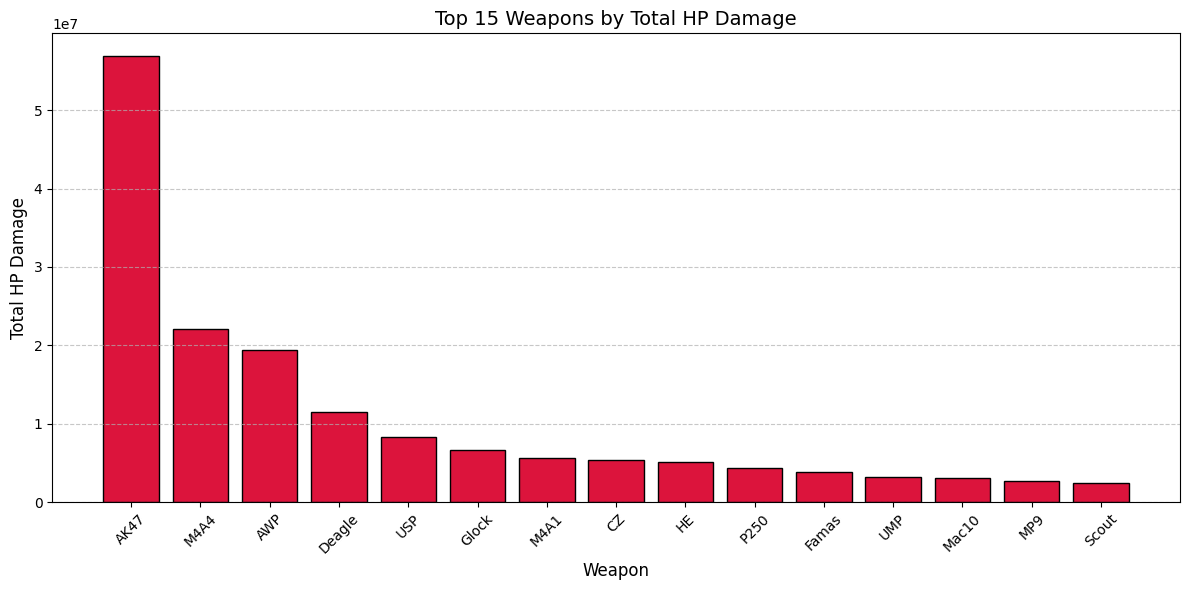

Highest damage weapon: AK47


In [12]:
weapon_dmg = dmg.groupby('wp')['hp_dmg'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(weapon_dmg.index, weapon_dmg.values, color='crimson', edgecolor='black')
plt.title('Top 15 Weapons by Total HP Damage', fontsize=14)
plt.xlabel('Weapon', fontsize=12)
plt.ylabel('Total HP Damage', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Highest damage weapon: {weapon_dmg.index[0]}")

**CONCLUSION**

1. **Most Played Map**: Inferno, Mirage and Dust2 dominate the professional map pool, reflecting their balanced and competitive design loved by top teams.

2. **Top Teams**: Liquid and Astralis are the most successful teams by total map wins, confirming their dominance in the CS:GO pro scene during this period.

3. **CT Side Advantage**: CT side wins 51.1% of rounds vs T side's 48.9%, confirming the widely held belief that CT side has a slight defensive advantage in professional play.

4. **Most Damaging Weapon**: The AK-47 deals by far the most total damage, followed by M4A4 and AWP — confirming that rifle mastery is the most important skill in CS:GO.

**BUSINESS INFERENCE**

**For Game Developers**: The slight CT advantage (51.1%) suggests the game is well balanced but minor T-side economy or utility adjustments could bring it closer to 50/50.

**For Esports Teams**: Focusing practice on Inferno, Mirage and Dust2 gives the highest competitive return since these maps appear most in professional rotations.

**For Players**: Investing time in AK-47 and M4A4 aim training is the single highest-impact skill improvement based on total damage output data.

**FUTURE WORK**

- **Economy Analysis**: Using `economy.csv` to study how team spending affects win rates round by round.
- **Player Rating Analysis**: Using `players.csv` to identify which stats best predict match winners.
- **Map-Weapon Correlation**: Analyzing which weapons are most effective on specific maps.